## Group Details
*Group #25 members: Sam Chung, Anthony Shen, Lewis Tu, Allie Zong*

*Project Number: 25 (Day-ahead electricity spot price forecasting)*


## Background/Research Question

We wish to predict day-ahead market prices for PJM Interconnection. These prices are particularly important because they determine the market clearing price for each day of energy generation and the generation mix that is used to meet energy demand. These prices are set by the system operator (PJM) the afternoon before the day they go into effect. This is done by forecasting demand and soliciting bids from different electricity generators at which point the price of the last MW of energy is set as the market price.

These prices are important to predict accurately for a variety of reasons. If we are able to predict these prices accurately, we can have a more efficient allocation of our generating and transmission resources. Predicting these prices also provides an opportunity for generators (suppliers) to improve the accuracy of their bids and make the most money from the power that they are producing. Additionally, proper day-ahead price prediction is useful in reducing real-time market adjustments which are often more expensive for the demand side. Overall, if we are able to predict day-ahead wholesale prices more accurately (which represent around 80% of the total market volume), we can increase the efficiency of grid operations and improve the outcomes for both demand and supply.

*Research Question: How accurately can we predict PJM day-ahead electricity prices using a neural network trained on available historical market and system data?*

## Data Source and Predictors 

The data we use is from the PJM website https://dataminer2.pjm.com/list, and PJM also uses this data to predict their official day-ahead prices. The predicted variable (the response variable) is the predicted day-ahead price per hour. As for our predictors, we used the following:
- Load forecast: historical load forecast. Load = demand of electricity. The time the forecast is released is ‘evaluated_at_ept’, forecasted time is ‘forecast_hour_beginning_ept’, forecasted load is ‘forecast_load_mw’.
- Historical price data: day, hour, price. Indicates the predicted day-ahead price per hour published by PJM at around 1:30pm per day.
- Generation by fuel type: coal_mw, gas_mw, nuclear_mw, wind_mw, solar_mw, hydro_mw, oil_mw, storage_mw, multiple_fuels_mw, other_renewables_mw.
- Forecasted generation outages: forecast_gen_outage_mw_rto. Expected MW of generation PJM expects to be unavailable at that hour for the region.
- Time information: Hour, day_of_week, month, is_weekend, season, is_holiday.


## Data Preprocessing

In [3]:
import pandas as pd
import numpy as np
import holidays

# -----------------------------
# 1. LOAD DATA
# -----------------------------
path = "./data/"

lmp = pd.read_csv(path + "da_hrl_lmps (1).csv")
load_fcst = pd.read_csv(path + "load_frcstd_hist.csv")
gen = pd.read_csv(path + "gen_by_fuel.csv")
outages_raw = pd.read_csv(path + "frcstd_gen_outages.csv")

# -----------------------------
# 2. TARGET: whole PJM (pnode_id=1), day-ahead total LMP → total_lmp_da
# -----------------------------
lmp = lmp.loc[lmp["pnode_id"] == 1].copy()
lmp["datetime_beginning_ept"] = pd.to_datetime(lmp["datetime_beginning_ept"])
lmp = lmp.sort_values("datetime_beginning_ept")
lmp = lmp.drop_duplicates(subset=["datetime_beginning_ept"], keep="last")
lmp = lmp.set_index("datetime_beginning_ept")
lmp = lmp.rename(columns={"total_lmp_da": "price"})
lmp = lmp[["price"]]

# -----------------------------
# 3. LOAD FORECAST (7-day style file): forecast_hour_beginning_ept, forecast_load_mw
#    CSV has no datetime_beginning_ept; use RTO rows and latest evaluation per hour
# -----------------------------
load_fcst = load_fcst.loc[load_fcst["forecast_area"] == "RTO"].copy()
load_fcst["forecast_hour_beginning_ept"] = pd.to_datetime(load_fcst["forecast_hour_beginning_ept"])
load_fcst["evaluated_at_ept"] = pd.to_datetime(load_fcst["evaluated_at_ept"])
load_fcst = load_fcst.sort_values("evaluated_at_ept")
load_fcst = load_fcst.drop_duplicates(subset=["forecast_hour_beginning_ept"], keep="last")
load_fcst = load_fcst.set_index("forecast_hour_beginning_ept")
load_fcst = load_fcst.rename(columns={"forecast_load_mw": "load_forecast_mw"})
load_fcst = load_fcst[["load_forecast_mw"]]

# -----------------------------
# 4. GENERATION BY FUEL (wind/solar + full mix); fuel_type is title case in CSV
# -----------------------------
gen["datetime_beginning_ept"] = pd.to_datetime(gen["datetime_beginning_ept"])
gen = gen.sort_values("datetime_beginning_ept")
gen = gen.set_index("datetime_beginning_ept")

FUEL_MAP = {
    "Coal": "coal_mw",
    "Gas": "gas_mw",
    "Nuclear": "nuclear_mw",
    "Wind": "wind_mw",
    "Solar": "solar_mw",
    "Hydro": "hydro_mw",
    "Oil": "oil_mw",
    "Storage": "storage_mw",
    "Multiple Fuels": "multiple_fuels_mw",
    "Other Renewables": "other_renewables_mw",
}
gen_pivot = gen.pivot_table(
    index=gen.index,
    columns="fuel_type",
    values="mw",
    aggfunc="mean",
)
gen_pivot = gen_pivot.rename(columns=FUEL_MAP)
gen_pivot = gen_pivot[[c for c in FUEL_MAP.values() if c in gen_pivot.columns]]

# -----------------------------
# 5. FORECAST GENERATOR OUTAGES: forecast_gen_outage_mw_rto (daily; not hourly index)
#    Latest forecast_execution_date_ept per forecast_date; map each hour to that calendar day
# -----------------------------
outages = outages_raw.copy()
outages["forecast_date"] = pd.to_datetime(outages["forecast_date"])
outages["forecast_execution_date_ept"] = pd.to_datetime(outages["forecast_execution_date_ept"])
outages = outages.sort_values("forecast_execution_date_ept")
outages = outages.drop_duplicates(subset=["forecast_date"], keep="last")
outages = outages.set_index(outages["forecast_date"].dt.normalize())
outages = outages[["forecast_gen_outage_mw_rto"]]

# -----------------------------
# 6. MERGE
# -----------------------------
df = lmp.join(load_fcst, how="left")
df = df.join(gen_pivot, how="left")
df["forecast_gen_outage_mw_rto"] = outages["forecast_gen_outage_mw_rto"].reindex(
    df.index.normalize()
).to_numpy()

df = df.sort_index()
print("Missing values before ffill:")
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))
print("Total missing before ffill:", int(df.isna().sum().sum()))
df = df.ffill(limit=3)

# -----------------------------
# 7. CALENDAR + CYCLICAL
# -----------------------------
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)


def get_season(month):
    if month in [12, 1, 2]:
        return 0
    if month in [3, 4, 5]:
        return 1
    if month in [6, 7, 8]:
        return 2
    return 3


df["season"] = df["month"].map(get_season)

us_holidays = holidays.US()
df["is_holiday"] = np.array([d.date() in us_holidays for d in df.index], dtype=int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# -----------------------------
# 8. LAGS / DERIVED (lagged price per plan)
# -----------------------------
df["price_lag_1"] = df["price"].shift(1)
df["price_lag_24"] = df["price"].shift(24)
df["wind_mw"] = df["wind_mw"].fillna(0)
df["solar_mw"] = df["solar_mw"].fillna(0)
df["renewable_mw"] = df["wind_mw"] + df["solar_mw"]
df["price_roll_24"] = df["price"].rolling(24).mean()

df = df.dropna()

# -----------------------------
# 9. SAVE initial_data.csv
# -----------------------------
out = df.reset_index()
out.to_csv("initial_data.csv", index=False)
print(out.head())
print(out.shape)

/var/folders/16/1bnwsg_12gqcf7fy1bfqhkp80000gn/T/ipykernel_53524/1647723572.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lmp["datetime_beginning_ept"] = pd.to_datetime(lmp["datetime_beginning_ept"])
/var/folders/16/1bnwsg_12gqcf7fy1bfqhkp80000gn/T/ipykernel_53524/1647723572.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  load_fcst["forecast_hour_beginning_ept"] = pd.to_datetime(load_fcst["forecast_hour_beginning_ept"])
/var/folders/16/1bnwsg_12gqcf7fy1bfqhkp80000gn/T/ipykernel_53524/1647723572.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gen["datetime_b

Missing values before ffill:
forecast_gen_outage_mw_rto    24
coal_mw                        6
gas_mw                         6
nuclear_mw                     6
wind_mw                        6
solar_mw                       6
hydro_mw                       6
oil_mw                         6
storage_mw                     6
multiple_fuels_mw              6
other_renewables_mw            6
dtype: int64
Total missing before ffill: 84
  datetime_beginning_ept      price  load_forecast_mw  coal_mw   gas_mw  \
0    2025-04-08 00:00:00  48.900998             83408  14591.0  33258.0   
1    2025-04-08 01:00:00  46.402496             82157  14779.0  32231.0   
2    2025-04-08 02:00:00  45.297246             81865  14776.0  31352.0   
3    2025-04-08 03:00:00  46.532548             82493  14694.0  31658.0   
4    2025-04-08 04:00:00  48.516346             81641  14732.0  32245.0   

   nuclear_mw  wind_mw  solar_mw  hydro_mw  oil_mw  ...  season  is_holiday  \
0     29350.0   4426.0      67.0  

In [3]:
out.columns

Index(['datetime_beginning_ept', 'price', 'load_forecast_mw', 'coal_mw',
       'gas_mw', 'nuclear_mw', 'wind_mw', 'solar_mw', 'hydro_mw', 'oil_mw',
       'storage_mw', 'multiple_fuels_mw', 'other_renewables_mw',
       'forecast_gen_outage_mw_rto', 'hour', 'day_of_week', 'month',
       'is_weekend', 'season', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'price_lag_1', 'price_lag_24', 'renewable_mw',
       'price_roll_24'],
      dtype='str')

## EDA

Shape: (8736, 29)
Date range: 2025-04-08 00:00:00 to 2026-04-07 00:00:00
Duplicate timestamps: 0
Missing values (top 10):
price                  0
month                  0
total_generation_mw    0
price_roll_24          0
renewable_mw           0
price_lag_24           0
price_lag_1            0
dow_cos                0
dow_sin                0
hour_cos               0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
price,8736.0,57.230325,78.984193,11.843864,29.306755,38.696991,55.642239,2314.581972
price_capped,8736.0,54.810155,56.901542,16.012730,29.306755,38.696991,55.642239,387.917368
load_forecast_mw,8736.0,95965.323832,17503.246518,63788.000000,83376.500000,92805.500000,106430.500000,160698.000000
total_generation_mw,8736.0,100193.226419,17265.730627,68553.000000,87072.750000,97177.000000,110459.250000,162721.000000
renewable_mw,8736.0,6555.006181,4185.413265,57.000000,2921.000000,6166.500000,9280.750000,19564.000000
forecast_gen_outage_mw_rto,8736.0,18352.349130,18906.425687,0.000000,1755.000000,11235.500000,34224.000000,57127.000000


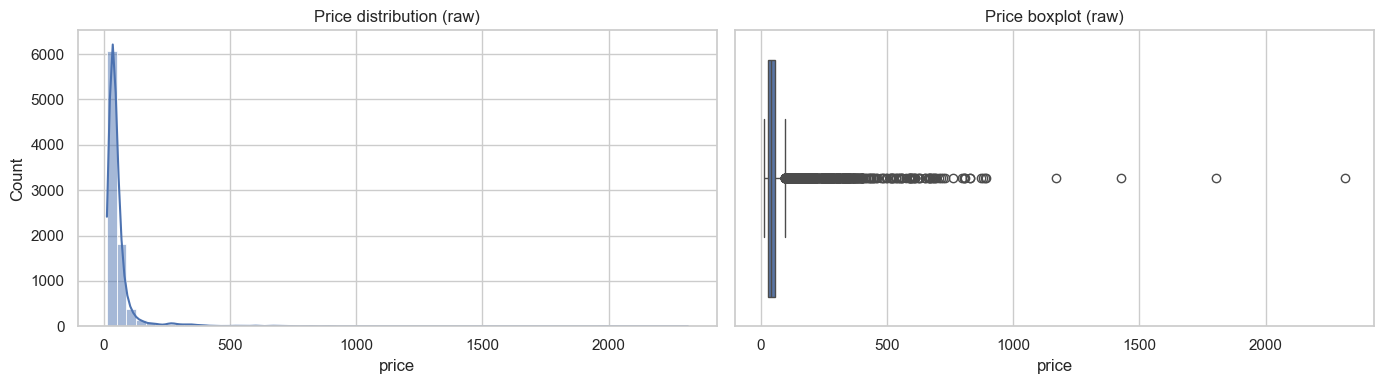

In [ ]:
# EDA setup + sanity checks
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

eda = pd.read_csv("initial_data.csv")
eda["datetime_beginning_ept"] = pd.to_datetime(eda["datetime_beginning_ept"])
eda = eda.sort_values("datetime_beginning_ept").set_index("datetime_beginning_ept")

fuel_cols = [
    "coal_mw", "gas_mw", "nuclear_mw", "wind_mw", "solar_mw",
    "hydro_mw", "oil_mw", "storage_mw", "multiple_fuels_mw", "other_renewables_mw"
]
eda["total_generation_mw"] = eda[fuel_cols].sum(axis=1)

q01, q99 = eda["price"].quantile([0.01, 0.99])
eda["price_capped"] = eda["price"].clip(lower=q01, upper=q99)

print("Shape:", eda.shape)
print("Date range:", eda.index.min(), "to", eda.index.max())
print("Duplicate timestamps:", eda.index.duplicated().sum())
print("Missing values (top 10):")
print(eda.isna().sum().sort_values(ascending=False).head(10))

display(
    eda[["price", "price_capped", "load_forecast_mw", "total_generation_mw", "renewable_mw", "forecast_gen_outage_mw_rto"]]
    .describe()
    .T
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(eda["price"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Price distribution (raw)")
sns.boxplot(x=eda["price"], ax=axes[1])
axes[1].set_title("Price boxplot (raw)")
plt.tight_layout()
plt.show()

### 1) Price over time 

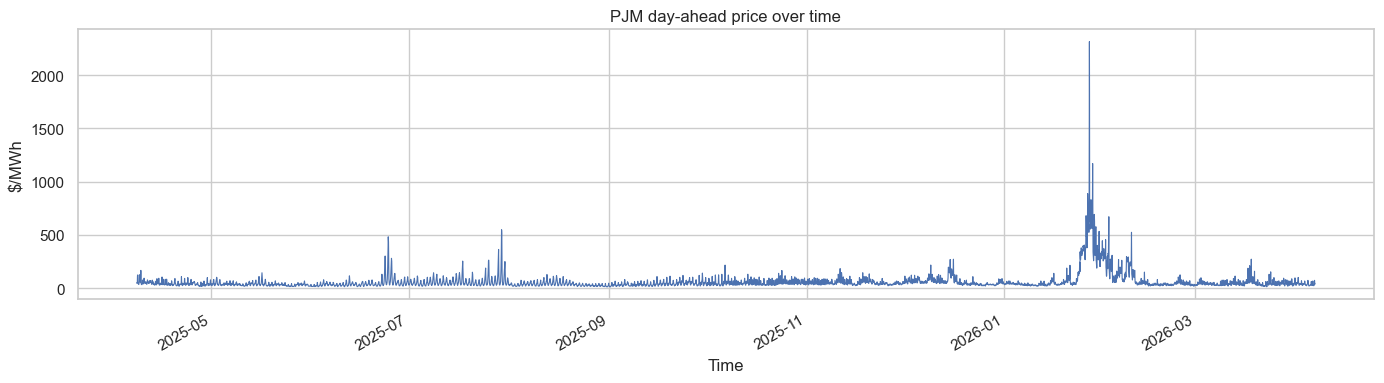

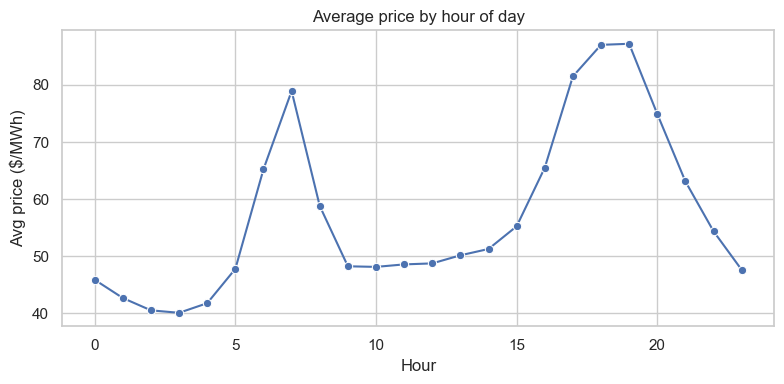

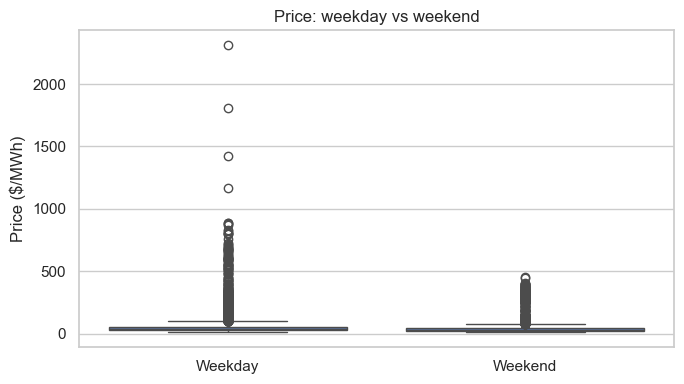

In [2]:
# Full timeline
plt.figure(figsize=(14, 4))
eda["price"].plot(linewidth=0.8)
plt.title("PJM day-ahead price over time")
plt.ylabel("$/MWh")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

# Average hourly profile
hourly_profile = eda.groupby("hour")["price"].mean()
plt.figure(figsize=(8, 4))
sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, marker="o")
plt.title("Average price by hour of day")
plt.xlabel("Hour")
plt.ylabel("Avg price ($/MWh)")
plt.tight_layout()
plt.show()

# Weekday vs weekend
tmp = eda[["price", "is_weekend"]].copy()
tmp["day_type"] = np.where(tmp["is_weekend"] == 1, "Weekend", "Weekday")
plt.figure(figsize=(7, 4))
sns.boxplot(data=tmp, x="day_type", y="price")
plt.title("Price: weekday vs weekend")
plt.xlabel("")
plt.ylabel("Price ($/MWh)")
plt.tight_layout()
plt.show()

### 2) Load forecast and outages vs price

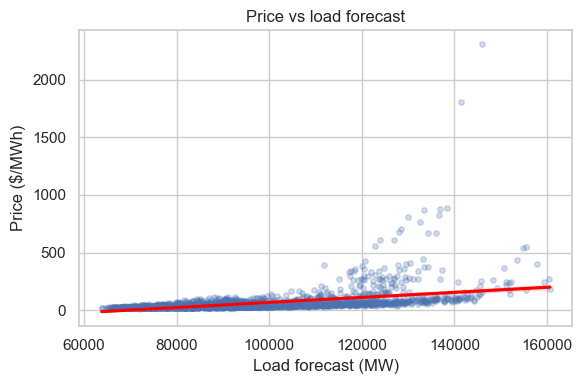

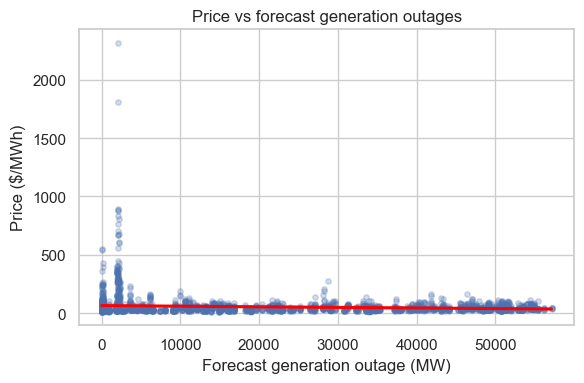

In [6]:
# Scatter + trend: load forecast vs price
plt.figure(figsize=(6, 4))
sns.regplot(
    data=eda.sample(min(len(eda), 3000), random_state=42),
    x="load_forecast_mw",
    y="price",
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "red"}
 )
plt.title("Price vs load forecast")
plt.xlabel("Load forecast (MW)")
plt.ylabel("Price ($/MWh)")
plt.tight_layout()
plt.show()

# Scatter + trend: outages vs price
plt.figure(figsize=(6, 4))
sns.regplot(
    data=eda.sample(min(len(eda), 3000), random_state=42),
    x="forecast_gen_outage_mw_rto",
    y="price",
    scatter_kws={"alpha": 0.25, "s": 15},
    line_kws={"color": "red"}
 )
plt.title("Price vs forecast generation outages")
plt.xlabel("Forecast generation outage (MW)")
plt.ylabel("Price ($/MWh)")
plt.tight_layout()
plt.show()

### 3) Generation and mix relationships

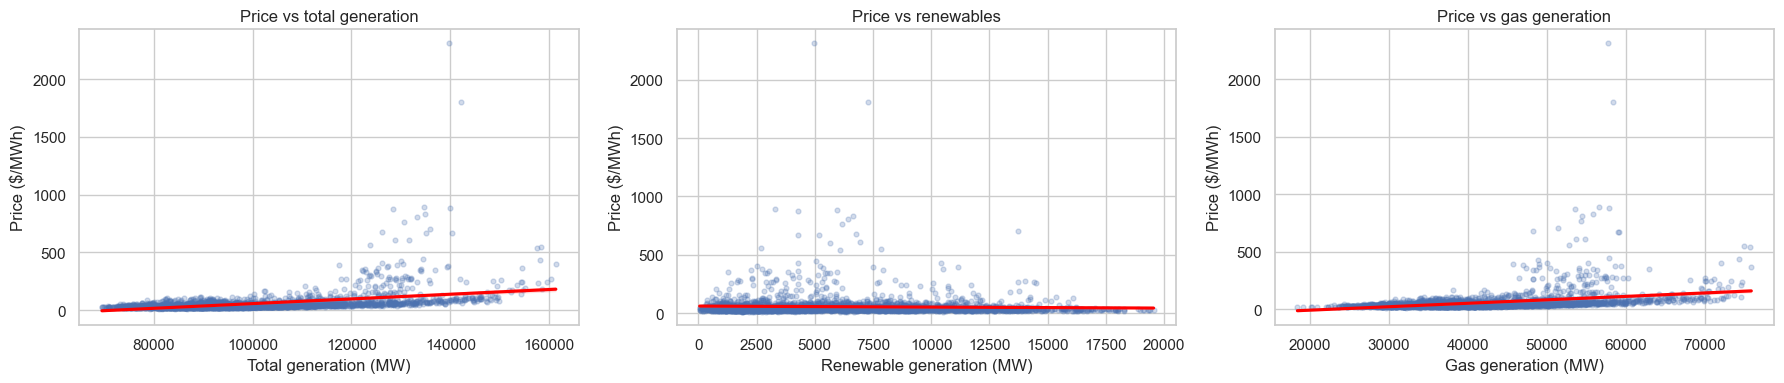

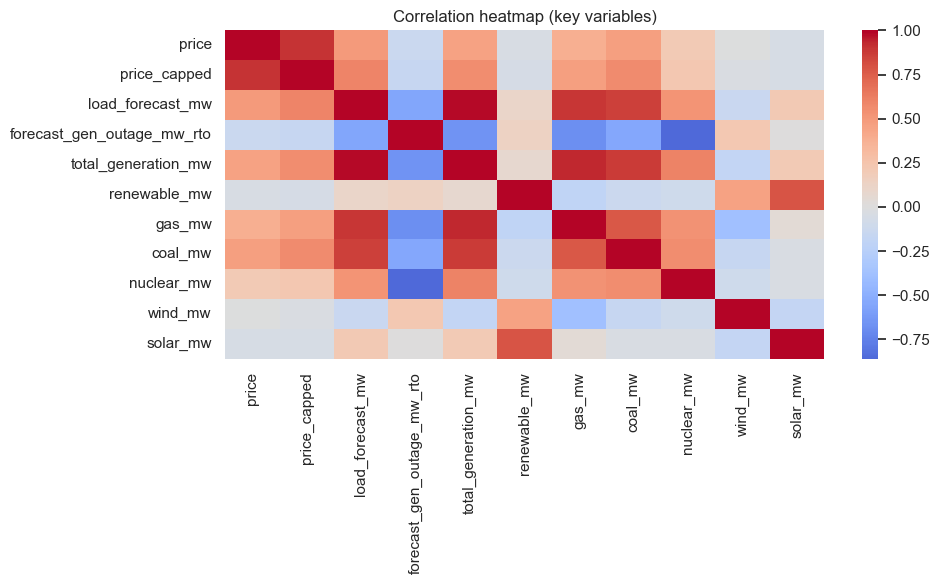

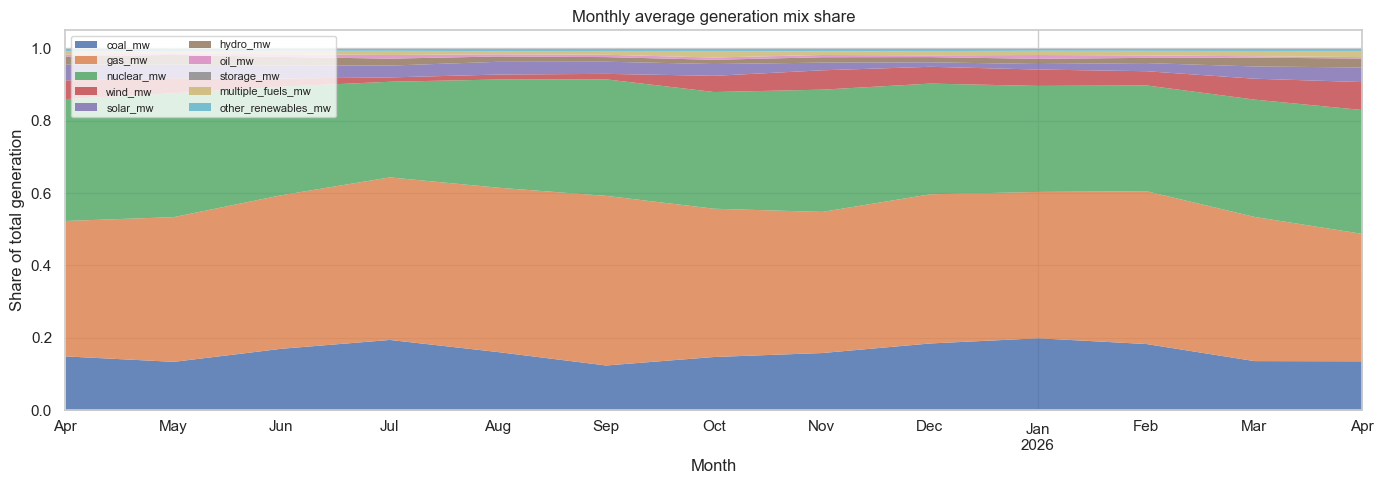

In [4]:
sampled = eda.sample(min(len(eda), 3000), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.regplot(data=sampled, x="total_generation_mw", y="price", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Price vs total generation")
axes[0].set_xlabel("Total generation (MW)")
axes[0].set_ylabel("Price ($/MWh)")

sns.regplot(data=sampled, x="renewable_mw", y="price", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("Price vs renewables")
axes[1].set_xlabel("Renewable generation (MW)")
axes[1].set_ylabel("Price ($/MWh)")

sns.regplot(data=sampled, x="gas_mw", y="price", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"}, ax=axes[2])
axes[2].set_title("Price vs gas generation")
axes[2].set_xlabel("Gas generation (MW)")
axes[2].set_ylabel("Price ($/MWh)")
plt.tight_layout()
plt.show()

corr_cols = [
    "price", "price_capped", "load_forecast_mw", "forecast_gen_outage_mw_rto",
    "total_generation_mw", "renewable_mw", "gas_mw", "coal_mw", "nuclear_mw", "wind_mw", "solar_mw"
]
corr = eda[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap (key variables)")
plt.tight_layout()
plt.show()

# Monthly average generation mix share
mix_monthly = eda[fuel_cols].resample("MS").mean()
mix_share = mix_monthly.div(mix_monthly.sum(axis=1), axis=0)

plt.figure(figsize=(14, 5))
mix_share.plot.area(ax=plt.gca(), alpha=0.85, linewidth=0)
plt.title("Monthly average generation mix share")
plt.xlabel("Month")
plt.ylabel("Share of total generation")
plt.legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

### 4) Seasonality 

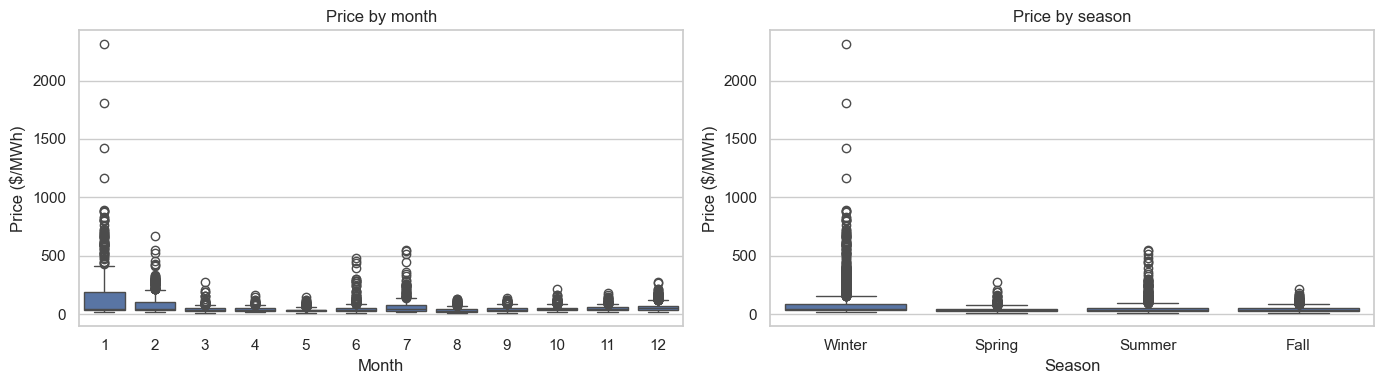

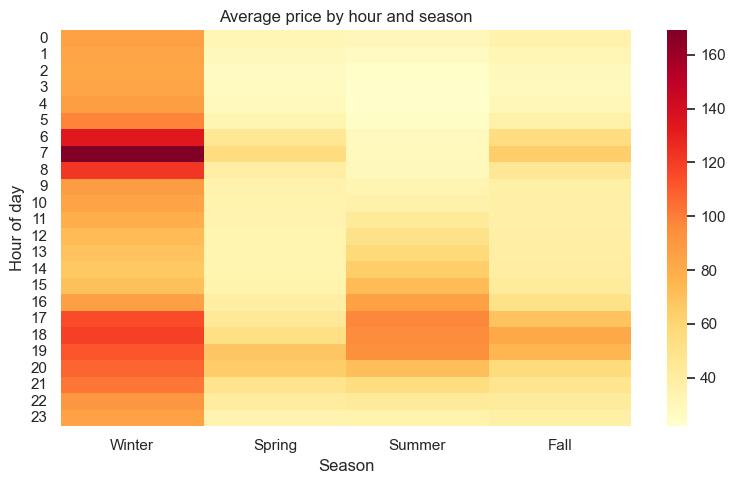

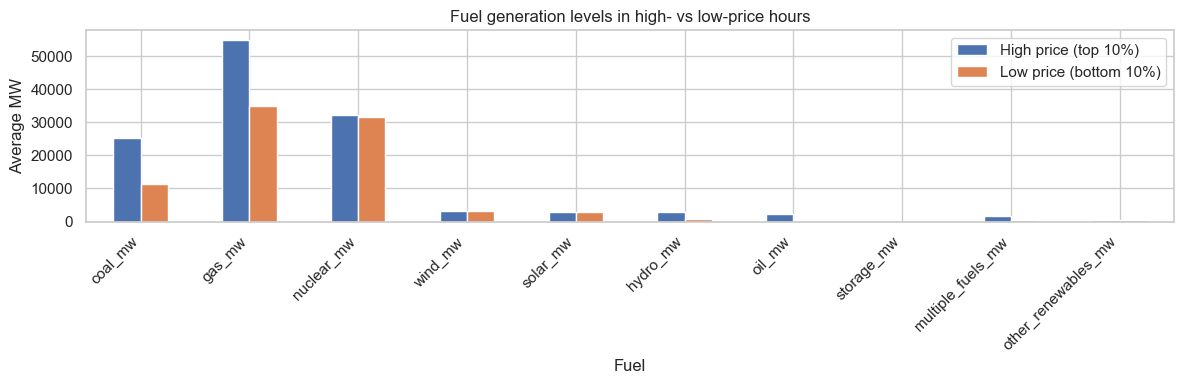

In [5]:
# Month and season distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=eda, x="month", y="price", ax=axes[0])
axes[0].set_title("Price by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Price ($/MWh)")

season_map = {0: "Winter", 1: "Spring", 2: "Summer", 3: "Fall"}
season_plot = eda.copy()
season_plot["season_label"] = season_plot["season"].map(season_map)
sns.boxplot(data=season_plot, x="season_label", y="price", order=["Winter", "Spring", "Summer", "Fall"], ax=axes[1])
axes[1].set_title("Price by season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Price ($/MWh)")
plt.tight_layout()
plt.show()

# Hour-by-season heatmap
heat = eda.pivot_table(index="hour", columns="season", values="price", aggfunc="mean")
heat = heat.rename(columns=season_map)

plt.figure(figsize=(8, 5))
sns.heatmap(heat, cmap="YlOrRd")
plt.title("Average price by hour and season")
plt.xlabel("Season")
plt.ylabel("Hour of day")
plt.tight_layout()
plt.show()

# High-price vs low-price fuel mix comparison
p90 = eda["price"].quantile(0.90)
p10 = eda["price"].quantile(0.10)
high_mix = eda.loc[eda["price"] >= p90, fuel_cols].mean()
low_mix = eda.loc[eda["price"] <= p10, fuel_cols].mean()
mix_compare = pd.DataFrame({"High price (top 10%)": high_mix, "Low price (bottom 10%)": low_mix})

mix_compare.plot(kind="bar", figsize=(12, 4))
plt.title("Fuel generation levels in high- vs low-price hours")
plt.xlabel("Fuel")
plt.ylabel("Average MW")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5) Autocorrelation

Correlation(price, price_lag_1):  0.946
Correlation(price, price_lag_24): 0.814


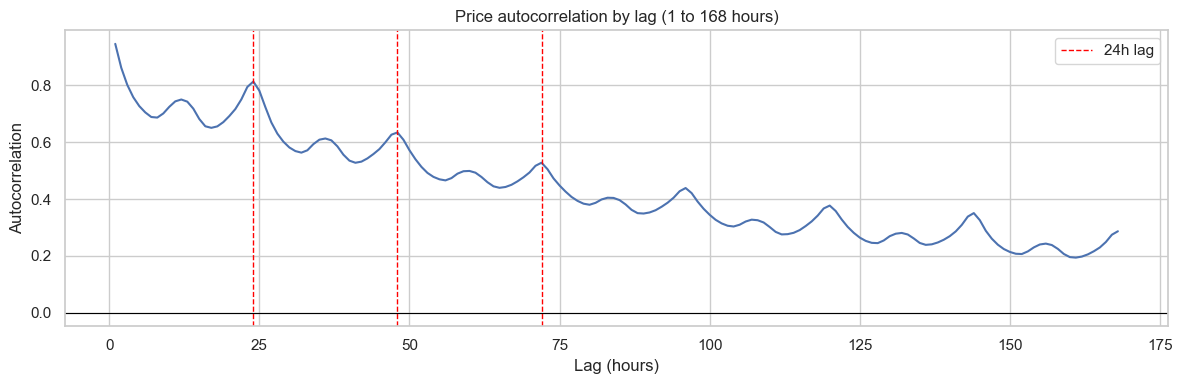

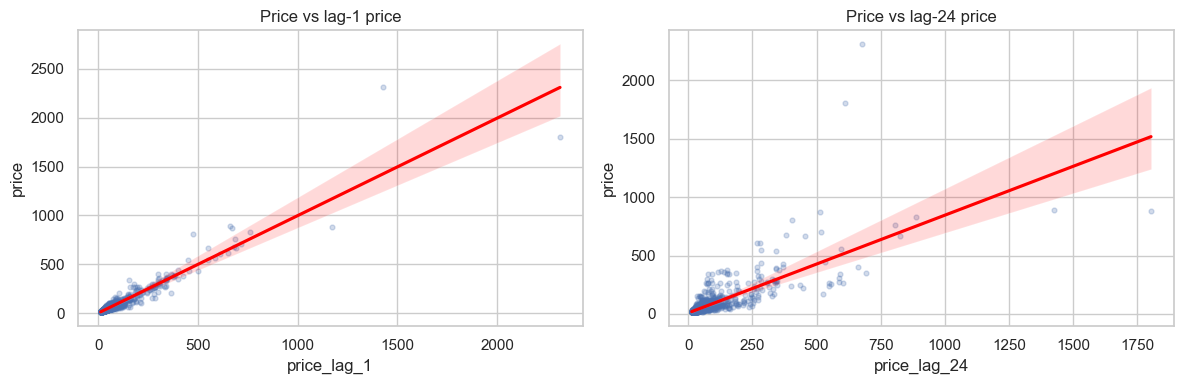

In [7]:
# Correlation with engineered lag features
lag1_corr = eda[["price", "price_lag_1"]].corr().iloc[0, 1]
lag24_corr = eda[["price", "price_lag_24"]].corr().iloc[0, 1]
print(f"Correlation(price, price_lag_1):  {lag1_corr:.3f}")
print(f"Correlation(price, price_lag_24): {lag24_corr:.3f}")

# Autocorrelation profile for first 7 days of lags (hourly data)
max_lag = 24 * 7
acf_vals = [eda["price"].autocorr(lag=i) for i in range(1, max_lag + 1)]
lags = np.arange(1, max_lag + 1)

plt.figure(figsize=(12, 4))
sns.lineplot(x=lags, y=acf_vals)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(24, color="red", linestyle="--", linewidth=1, label="24h lag")
plt.axvline(48, color="red", linestyle="--", linewidth=1)
plt.axvline(72, color="red", linestyle="--", linewidth=1)
plt.title("Price autocorrelation by lag (1 to 168 hours)")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.legend()
plt.tight_layout()
plt.show()

# Scatter checks for lag-1 and lag-24
sample_lag = eda.sample(min(len(eda), 3000), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(
    data=sample_lag, x="price_lag_1", y="price",
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "red"}, ax=axes[0]
 )
axes[0].set_title("Price vs lag-1 price")
axes[0].set_xlabel("price_lag_1")
axes[0].set_ylabel("price")

sns.regplot(
    data=sample_lag, x="price_lag_24", y="price",
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "red"}, ax=axes[1]
 )
axes[1].set_title("Price vs lag-24 price")
axes[1].set_xlabel("price_lag_24")
axes[1].set_ylabel("price")

plt.tight_layout()
plt.show()

### 6) Rolling standard deviation and holiday impact

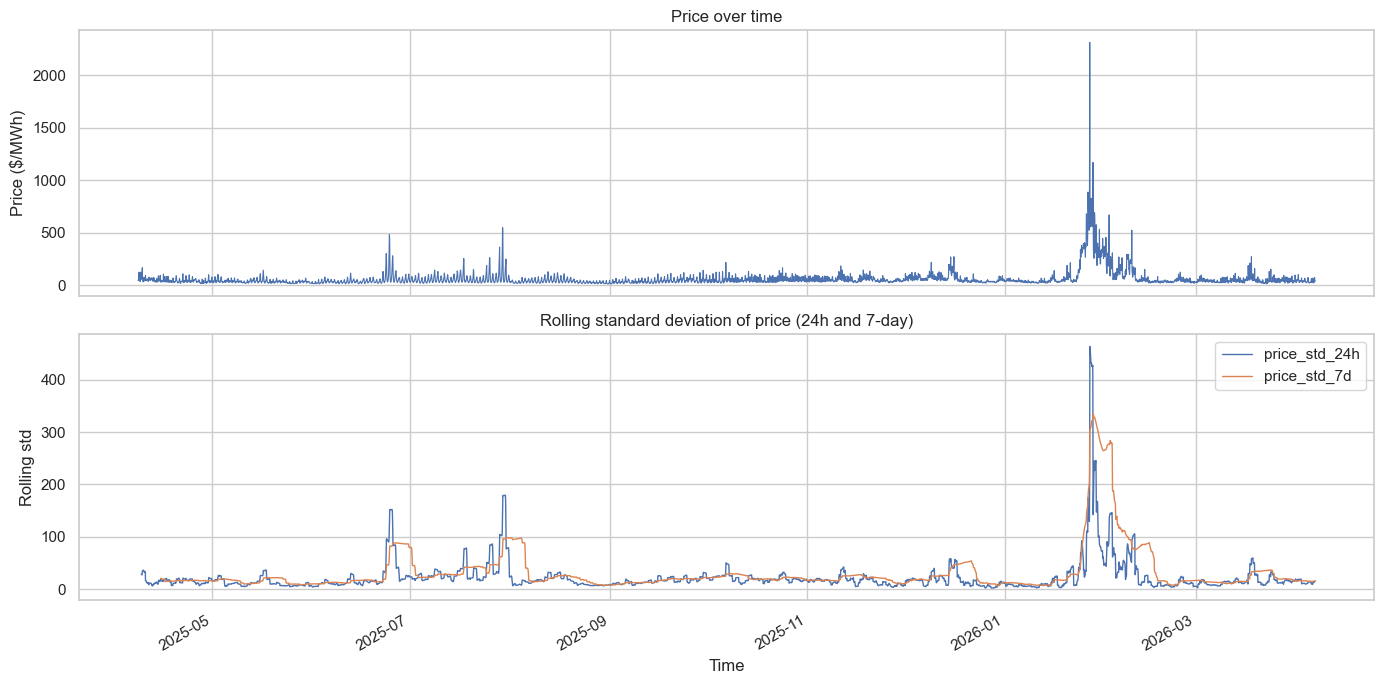

Weekday-only holiday vs non-holiday summary:


,count,mean,median,std
is_holiday,,,,
Weekday non-holiday,5977,60.742912,40.490663,87.071022
Weekday holiday,264,40.746406,35.380764,24.165209


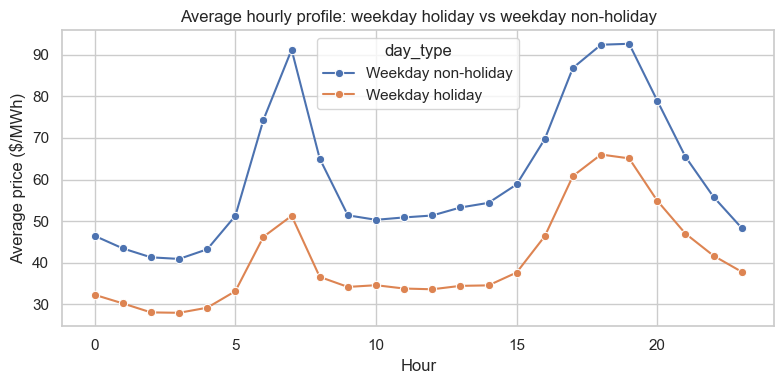

Mean hour-matched holiday effect (weekday only): -20.00 $/MWh


In [10]:
# Rolling standard deviation of price (volatility proxy)
eda["price_std_24h"] = eda["price"].rolling(24).std()
eda["price_std_7d"] = eda["price"].rolling(24 * 7).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
eda["price"].plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("Price over time")
axes[0].set_ylabel("Price ($/MWh)")

eda[["price_std_24h", "price_std_7d"]].plot(ax=axes[1], linewidth=1)
axes[1].set_title("Rolling standard deviation of price (24h and 7-day)")
axes[1].set_ylabel("Rolling std")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Holiday impact with bias control: weekdays only + hour-matched comparison
weekday_only = eda.loc[eda["day_of_week"] < 5].copy()
weekday_stats = (
    weekday_only.groupby("is_holiday")["price"]
    .agg(["count", "mean", "median", "std"])
    .rename(index={0: "Weekday non-holiday", 1: "Weekday holiday"})
)
print("Weekday-only holiday vs non-holiday summary:")
display(weekday_stats)

hourly_weekday = (
    weekday_only.groupby(["hour", "is_holiday"])["price"]
    .mean()
    .reset_index()
)
hourly_weekday["day_type"] = np.where(hourly_weekday["is_holiday"] == 1, "Weekday holiday", "Weekday non-holiday")

plt.figure(figsize=(8, 4))
sns.lineplot(data=hourly_weekday, x="hour", y="price", hue="day_type", marker="o")
plt.title("Average hourly profile: weekday holiday vs weekday non-holiday")
plt.xlabel("Hour")
plt.ylabel("Average price ($/MWh)")
plt.tight_layout()
plt.show()

hourly_pivot = hourly_weekday.pivot(index="hour", columns="is_holiday", values="price")
if 0 in hourly_pivot.columns and 1 in hourly_pivot.columns:
    matched_hour_diff = (hourly_pivot[1] - hourly_pivot[0]).mean()
    print(f"Mean hour-matched holiday effect (weekday only): {matched_hour_diff:.2f} $/MWh")
else:
    print("Not enough weekday holiday/non-holiday coverage for hour-matched effect estimate.")

## Summary of Findings
- The PJM day-ahead price series is strongly right-skewed, with rare but very large spikes; this suggests using robust error metrics and careful outlier handling in modeling.
- Prices show clear intraday structure (morning and evening peaks), which supports using hour-based and cyclical time features.
- Weekday pricing tends to be higher and more volatile than weekend pricing, indicating day-type effects are important.
- Load forecast has a positive relationship with price, consistent with tighter system conditions during higher demand periods.
- Generation composition matters: higher gas and total generation levels are associated with higher prices in this sample, while renewable output shows a weaker linear relationship.
- Lag features are very informative: correlation with `price_lag_1` is about 0.95 and with `price_lag_24` is about 0.81, showing strong short-term persistence and a meaningful daily cycle.
- Rolling volatility is regime-dependent: 24-hour and 7-day rolling standard deviations both surge during stress windows, especially around major spike periods.
- Holidays are associated with lower prices on average (about -20 $/MWh in this sample), though holiday sample size is limited.
- Winter periods appear to contribute a large share of extreme-price behavior, so seasonal interactions should be considered in later models.

## Future Work and Rescoping
**Future data additions**
- Add hourly weather features (temperature, humidity, heating/cooling degree days) to better explain demand-driven price variation.
- Add event/context features where possible (major outages, transmission constraints, fuel disruptions) to better capture drivers of price spikes.

**Method revisions for modeling**
- Start with lag-aware baseline models (e.g., persistence and regularized linear models using `price_lag_1`, `price_lag_24`, and calendar terms) and compare against non-lag baselines.
- Compare models on both raw `price` and transformed targets (e.g., log-price or capped-price variants) to handle heavy tails.
- Use time-aware validation (rolling or expanding windows) instead of random splits to prevent leakage.
- Test interaction effects between load, season, and generation mix to capture non-linear market behavior.